In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fashion-retail-sales/Fashion_Retail_Sales.csv


### Title: Fashion Retail Sales Dataset

#### Description: A dataset containing sales data from a fashion retail store, including product details, customer demographics, purchase behavior, and transaction information to analyze trends, customer preferences, and sales performance.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/fashion-retail-sales/Fashion_Retail_Sales.csv')

In [3]:
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


In [4]:
df.tail()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
3395,4118,Shorts,37.0,09-07-2023,2.7,Cash
3396,4056,Slippers,176.0,16-03-2023,2.5,Cash
3397,3991,Onesie,NaN,03-10-2022,2.4,Credit Card
3398,4042,Sandals,128.0,01-01-2023,1.8,Cash
3399,4001,Backpack,115.0,22-03-2023,1.4,Cash


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


In [6]:
df.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


In [7]:
df.isnull().sum()

Customer Reference ID      0
Item Purchased             0
Purchase Amount (USD)    650
Date Purchase              0
Review Rating            324
Payment Method             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Customer Reference ID      int64
Item Purchased            object
Purchase Amount (USD)    float64
Date Purchase             object
Review Rating            float64
Payment Method            object
dtype: object

In [10]:
df.columns

Index(['Customer Reference ID', 'Item Purchased', 'Purchase Amount (USD)',
       'Date Purchase', 'Review Rating', 'Payment Method'],
      dtype='object')

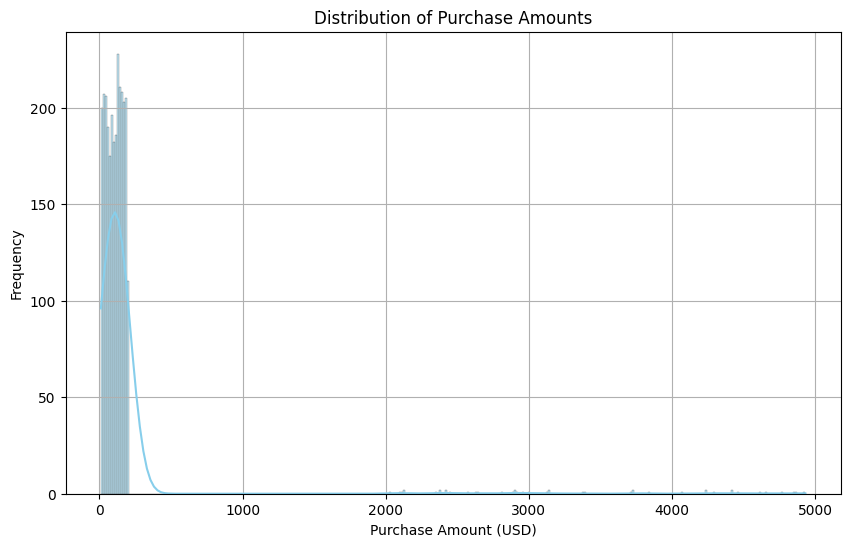

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Purchase Amount (USD)'], kde=True, color='skyblue')
plt.title('Distribution of Purchase Amounts')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

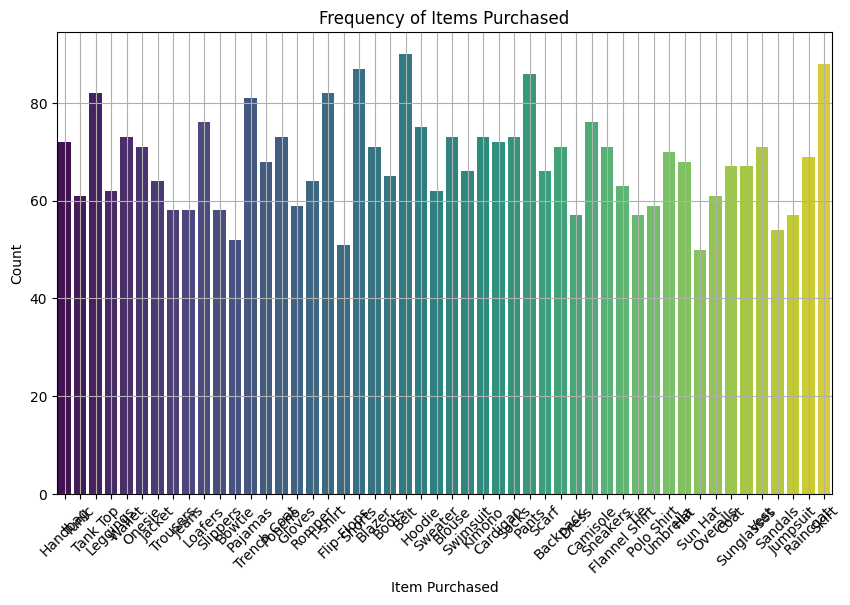

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Item Purchased', data=df, palette='viridis')
plt.title('Frequency of Items Purchased')
plt.xlabel('Item Purchased')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


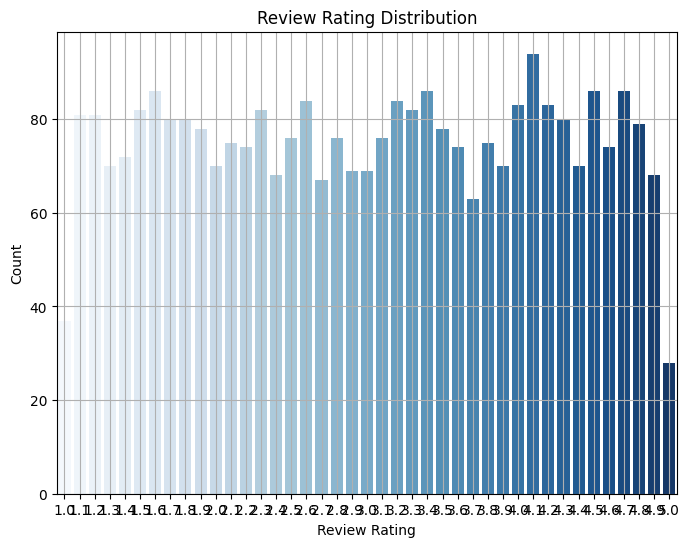

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Review Rating', data=df, palette='Blues')
plt.title('Review Rating Distribution')
plt.xlabel('Review Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

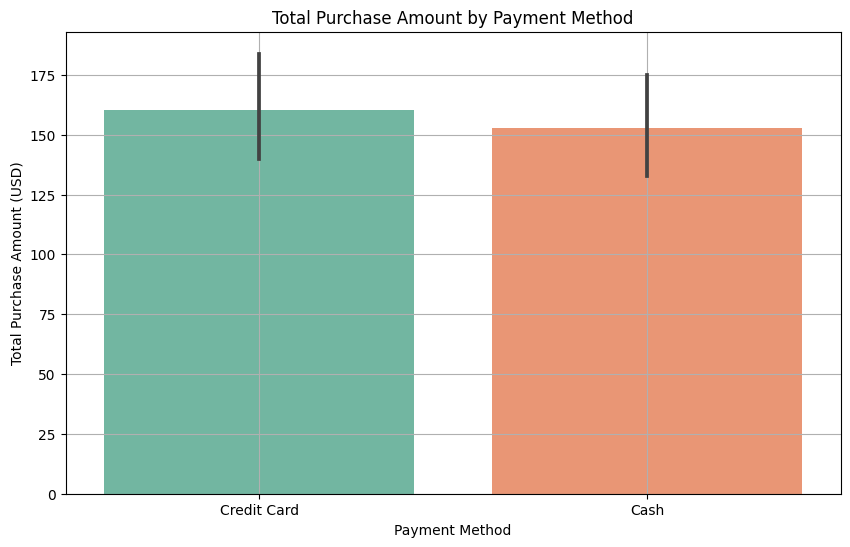

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Payment Method', y='Purchase Amount (USD)', data=df, palette='Set2')
plt.title('Total Purchase Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Purchase Amount (USD)')
plt.grid(True)
plt.show()

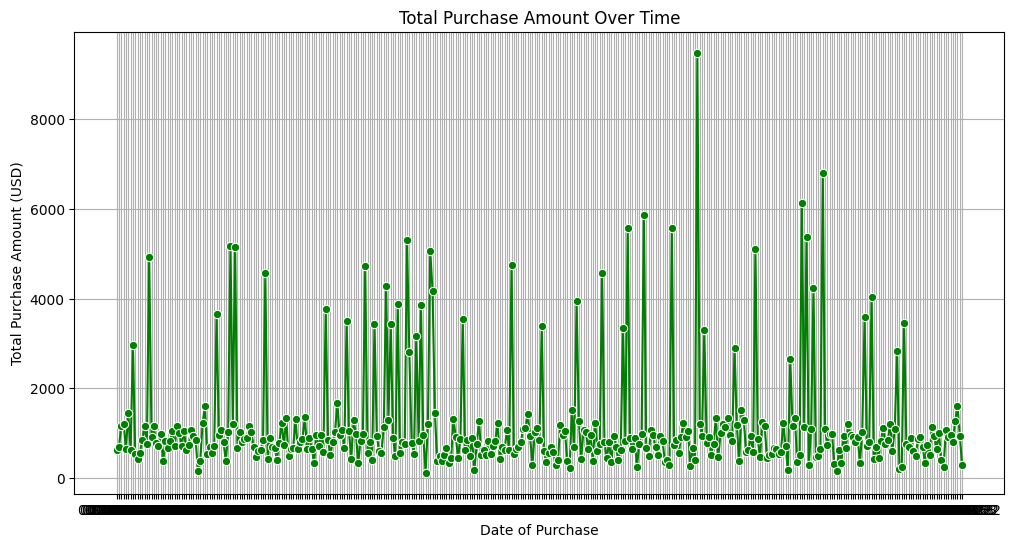

In [15]:
plt.figure(figsize=(12, 6))
df_grouped_by_date = df.groupby('Date Purchase')['Purchase Amount (USD)'].sum().reset_index()
sns.lineplot(x='Date Purchase', y='Purchase Amount (USD)', data=df_grouped_by_date, marker='o', color='green')
plt.title('Total Purchase Amount Over Time')
plt.xlabel('Date of Purchase')
plt.ylabel('Total Purchase Amount (USD)')
plt.grid(True)
plt.show()


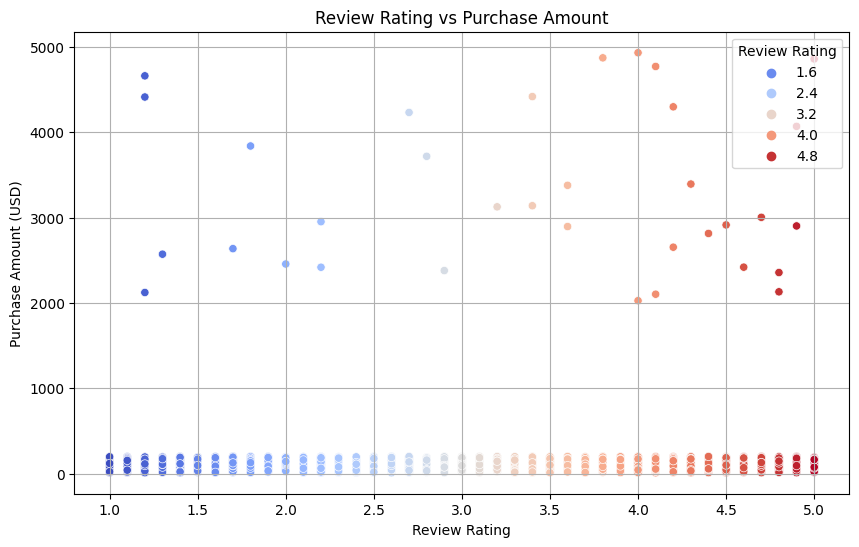

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Review Rating', y='Purchase Amount (USD)', data=df, hue='Review Rating', palette='coolwarm')
plt.title('Review Rating vs Purchase Amount')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')
plt.grid(True)
plt.show()


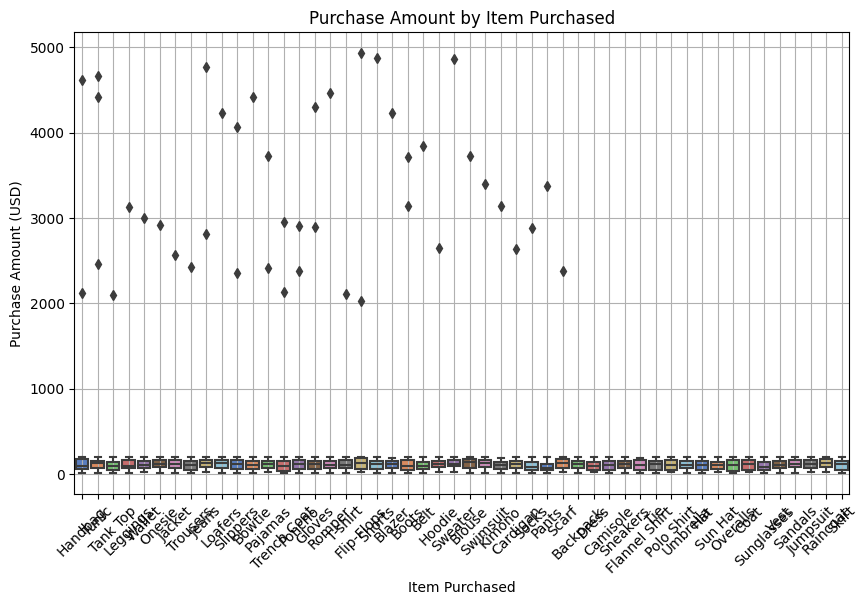

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Item Purchased', y='Purchase Amount (USD)', data=df, palette='muted')
plt.title('Purchase Amount by Item Purchased')
plt.xlabel('Item Purchased')
plt.ylabel('Purchase Amount (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Predictive modeling

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [19]:
# 1. Label Encoding for categorical columns
lab_col = ['Item Purchased', 'Date Purchase', 'Payment Method']
le = LabelEncoder()

for column in lab_col:
    df[column] = le.fit_transform(df[column])


In [20]:
# Drop rows with NaN values
df_cleaned = df.dropna()

# Recreate X and y after dropping missing values
X = df_cleaned.drop(columns=['Date Purchase', 'Customer Reference ID', 'Payment Method'])
y = df_cleaned['Payment Method']

# Proceed with train-test split using the cleaned data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


In [21]:
from sklearn.impute import SimpleImputer

# Create an imputer to fill missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')

# Apply imputation to the dataset (X contains the features)
X_imputed = imputer.fit_transform(X)


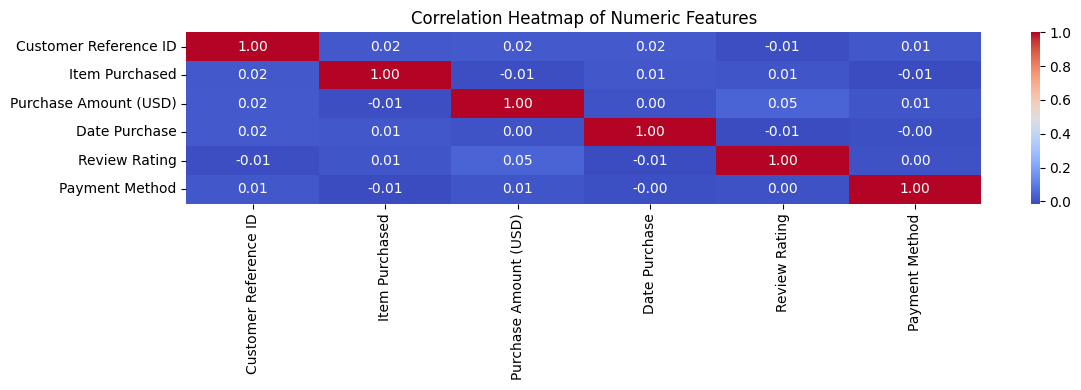

In [22]:
# 2. Correlation Matrix (after encoding)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 3:
    plt.figure(figsize=(12, 4))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

In [23]:
columns_to_scale = ['Item Purchased', 'Purchase Amount (USD)', 'Review Rating']
scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# 4. Prepare the features and target variable
X = df.drop(columns=['Date Purchase', 'Customer Reference ID', 'Payment Method'])
y = df['Payment Method']

In [24]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [25]:
# 6. Define models to train
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "K Neighbors": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(verbosity=0, use_label_encoder=False)
}

In [26]:
from sklearn.pipeline import Pipeline

In [27]:
# Define the pipeline steps: impute missing values, scale data, then fit the model
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with the mean
    ('scaler', StandardScaler()),  # Standardize features
    ('classifier', RandomForestClassifier())  # Replace with any model you want to use
])

# Train the model using the pipeline
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5015
Precision: 0.5003
Recall: 0.5015
F1 Score: 0.5000


# Thank you..pls upvote